In [11]:
import sys, os
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.set_option('display.float_format', '{:.2f}'.format)

fname = "../data/USDM_HUC2_UpperColorado_2000-2024.csv"
df = pd.read_csv(fname)
## compute % of area >=D2 
df['D2_D4_total'] = df['D2']+df['D3']+df['D4']
# add datetime
df['MapDate'] = pd.to_datetime(df['MapDate'], format="%Y%m%d")
drought_df = df.sort_values(by='MapDate')

# Assign water year (Oct–Sep)
drought_df["water_year"] = drought_df["MapDate"].dt.year
drought_df.loc[drought_df["MapDate"].dt.month >= 10, "water_year"] += 1

# Aggregate to annual mean % area in D2+
drought_wy = (
    drought_df
    .groupby("water_year")["D2_D4_total"]
    .mean()
)

# Sort properly
drought_df = drought_df.sort_values("MapDate")

# Get first and last D2_D4_pct in each water year
wy_change = (
    drought_df
    .groupby("water_year")
    .agg(
        D2_start=("D2_D4_total", "first"),
        D2_end=("D2_D4_total", "last")
    )
    .reset_index()
)

# Compute change
wy_change["D2_change"] = wy_change["D2_end"] - wy_change["D2_start"]

# Define melt season
melt = drought_df["MapDate"].dt.month.isin([4,5,6,7,8,9])

drought_melt = (
    drought_df[melt]
    .groupby("water_year")["D2_D4_total"]
    .mean()
    .reset_index()
    .rename(columns={"D2_D4_total": "D2_melt_mean"})
)

# Open Data
fname = "../out/UCRB_SNOTEL_tARgetv4_1990-2024_90-percentile.nc"
ds = xr.open_dataset(fname)

# Ensure binary integers
AR = ds['AR'].notnull().astype(int)
extreme = ds['extreme'].fillna(0).astype(int)

# Masks
mask_extreme_AR       = (extreme == 1) & (AR == 1)
mask_extreme_nonAR    = (extreme == 1) & (AR == 0)
mask_nonextreme_AR    = (extreme == 0) & (AR == 1)
mask_nonextreme_nonAR = (extreme == 0) & (AR == 0)

snow_months = [10,11,12,1,2,3,4,5]
month_mask = ds['time'].dt.month.isin(snow_months)

SWE = ds['SWE'].where(ds['SWE'] > 0)
SWE = SWE.where(month_mask)

# Compute annual total SWE per station
annual_station_SWE = (
    SWE.groupby('water_year')
           .sum(dim='time', skipna=True)
)

# Now compute climatological mean annual SWE per station
mean_annual_SWE_station = annual_station_SWE.mean(dim='water_year')

SWE_norm = SWE / mean_annual_SWE_station

# AR-only normalized SWE
SWE_AR = SWE_norm.where(AR == 1)

# Total normalized SWE across all days (positive SWE only)
SWE_total = SWE_norm

def seasonal_sum(da):
    return da.groupby('water_year').sum(dim='time', skipna=True).sum(dim='station', skipna=True)

sum_SWE_AR = seasonal_sum(SWE_AR)
sum_SWE_total = seasonal_sum(SWE_total)

AR_fraction = sum_SWE_AR / sum_SWE_total
AR_fraction_percent = AR_fraction * 100


# Apply masks
cat_extreme_AR       = SWE_norm.where(mask_extreme_AR)
cat_extreme_nonAR    = SWE_norm.where(mask_extreme_nonAR)
cat_nonextreme_AR    = SWE_norm.where(mask_nonextreme_AR)
cat_nonextreme_nonAR = SWE_norm.where(mask_nonextreme_nonAR)

# Group by water year and sum over time + station
def seasonal_sum(da):
    return (
        da.groupby('water_year')
          .sum(dim='time', skipna=True)
          .sum(dim='station', skipna=True)
    )

sum_extreme_AR       = seasonal_sum(cat_extreme_AR)
sum_extreme_nonAR    = seasonal_sum(cat_extreme_nonAR)
sum_nonextreme_AR    = seasonal_sum(cat_nonextreme_AR)
sum_nonextreme_nonAR = seasonal_sum(cat_nonextreme_nonAR)

# Convert to pandas DataFrame
df = pd.DataFrame({
    'non-extreme non-AR': sum_nonextreme_nonAR.values,
    'extreme non-AR': sum_extreme_nonAR.values,
    'non-extreme AR': sum_nonextreme_AR.values,
    'extreme AR': sum_extreme_AR.values,
}, index=sum_extreme_AR['water_year'].values)

df = df.sort_index()

common_years = df.index.intersection(drought_wy.index)

df_plot = df.loc[common_years]
drought_plot = drought_wy.loc[common_years]
AR_fraction_percent = AR_fraction_percent.loc[common_years]

# Y-axis:
# Total seasonal SWE accumulation (sum of daily ΔSWE across all stations)

# Break into 4 categories:

# Non-extreme, non-AR
# Non-extreme, AR
# Extreme, non-AR
# Extreme, AR

colors = ["#626C78", "#8C92AC", "#00629B", "#00C6D7"]

fig, ax1 = plt.subplots(figsize=(12,6))

# --- Stacked bars ---
bottom = np.zeros(len(df_plot))

for i, col in enumerate(df_plot.columns):
    ax1.bar(df_plot.index, df_plot[col], bottom=bottom, label=col, color=colors[i])
    bottom += df_plot[col].values

ax1.set_xlabel("Water Year")
ax1.set_ylabel("Normalized Seasonal SWE Accumulation")

# # --- Drought line ---
# ax2 = ax1.twinx()
# ax2.plot(drought_plot.index, drought_plot.values, color='k')
# ax2.set_ylabel("% Area in D2–D4")

# --- Shaded drought background ---


ax2 = ax1.twinx()
ax2.fill_between(
    drought_plot.index,
    0,
    drought_plot.values,
    color = "#c49a6c",
    alpha = 0.25,
    zorder=0
)
ax2.set_ylabel("% Area in D2–D4")
ax2.plot(AR_fraction_percent['water_year'], AR_fraction_percent.values, 
         color="#FF7F0E", marker='o', linewidth=2, label="AR Fraction (%)")

ax2.set_ylim(0, 100)  # percentage scale

# ax2.invert_yaxis()


plt.title("Seasonal SWE Contributions and Basin Drought Severity")

ax1.legend(loc="upper left")

plt.tight_layout()
plt.show()

swe_dict = {
    "Extreme AR": df_plot['extreme AR'].values,
    "Extreme Non-AR": df_plot['extreme non-AR'].values,
    "Total Non-AR": (
        df_plot['extreme non-AR'].values +
        df_plot['non-extreme non-AR'].values
    ),
    "Total AR": (
        df_plot['extreme AR'].values +
        df_plot['non-extreme AR'].values
    )
}

drought_dict = {
    "Same-Year Drought":
        drought_plot.values,

    "Lagged Melt-Season Drought":
        drought_melt['D2_melt_mean'].values
}

def plot_panel(ax, x, y, xlbl, ylbl):
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    rho, p_rho = stats.spearmanr(x, y)
    slope, intercept, r_value, p_lin, std_err = stats.linregress(x, y)

    # Scatter
    ax.scatter(x, y, alpha=0.8)

    # Regression line
    x_line = np.linspace(np.min(x), np.max(x), 100)
    ax.plot(x_line, slope * x_line + intercept)

    # Labels
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)

    # Stats annotation
    textstr = (
        f"ρ = {rho:.2f} (p={p_rho:.3f})\n"
        f"R² = {r_value**2:.2f} (p={p_lin:.3f})"
    )

    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            verticalalignment='top')

for drought_name, drought_vals in drought_dict.items():

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, (swe_name, swe_vals) in enumerate(swe_dict.items()):

        # Align for lagged case
        if "Lagged" in drought_name:
            x = swe_vals[:-1]
            y = drought_vals
        else:
            x = swe_vals
            y = drought_vals

        plot_panel(
            axes[i],
            x,
            y,
            f"Normalized {swe_name} SWE (Oct–Mar)",
            "Percent Area in D2+ (%)"
        )

        axes[i].set_title(swe_name)

    fig.suptitle(drought_name, fontsize=16)
    plt.tight_layout()
    plt.show()



results = []

for drought_name, drought_vals in drought_dict.items():
    
    for swe_name, swe_vals in swe_dict.items():
        
        # Align lagged case
        if "Lagged" in drought_name:
            x = swe_vals[:-1]
            y = drought_vals
        else:
            x = swe_vals
            y = drought_vals
        
        # Remove NaNs
        mask = np.isfinite(x) & np.isfinite(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        # Spearman
        rho, p_rho = stats.spearmanr(x_clean, y_clean)
        
        # Linear regression
        slope, intercept, r_value, p_lin, std_err = stats.linregress(x_clean, y_clean)
        
        results.append({
            "Drought Metric": drought_name,
            "SWE Metric": swe_name,
            "Spearman_rho": rho,
            "Spearman_p": p_rho,
            "Linear_R2": r_value**2,
            "Linear_p": p_lin,
            "Slope": slope
        })

# Convert to DataFrame
stats_df = pd.DataFrame(results)

# Optional: sort by strongest linear relationship
stats_df = stats_df.sort_values("Linear_R2", ascending=False)



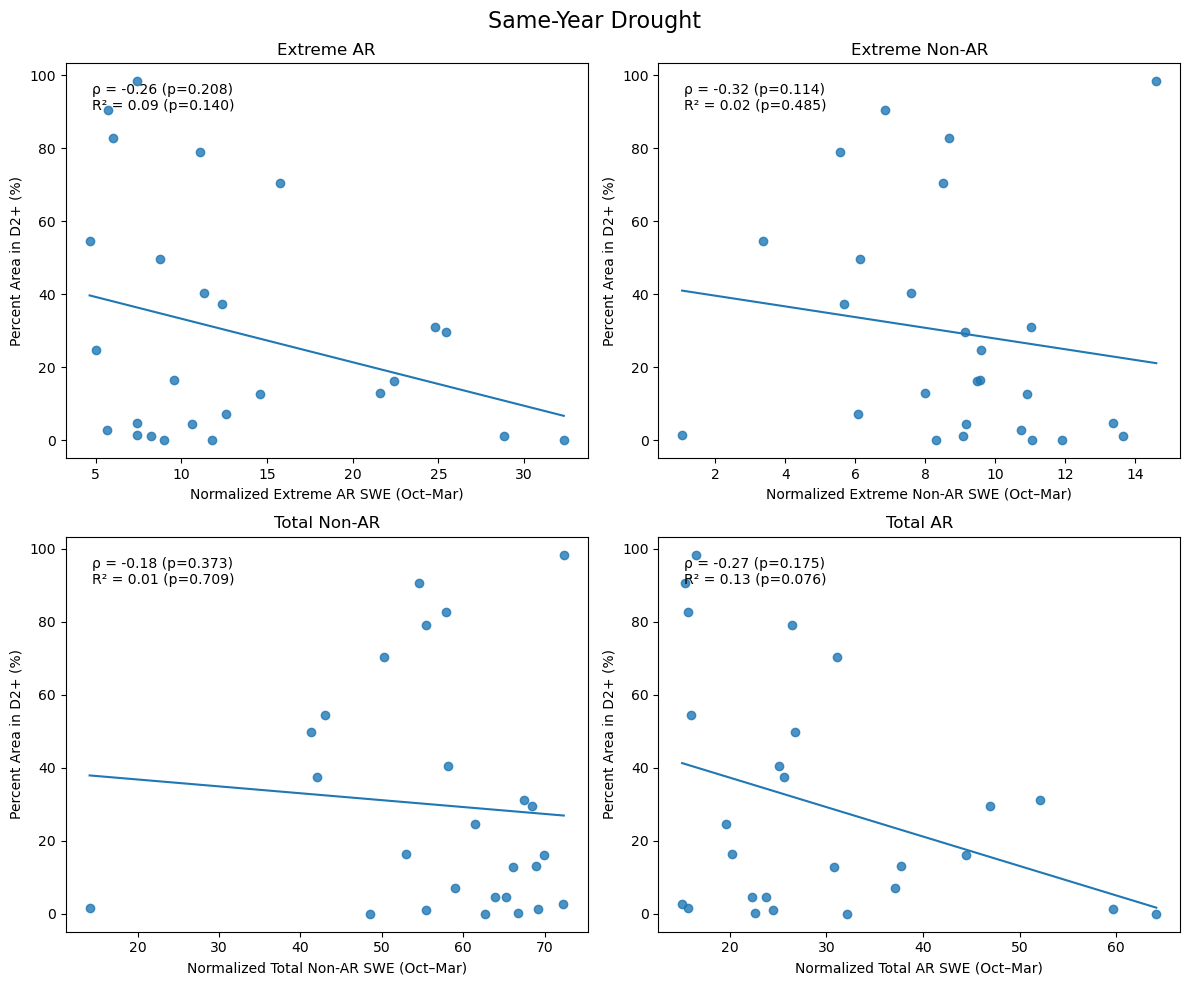

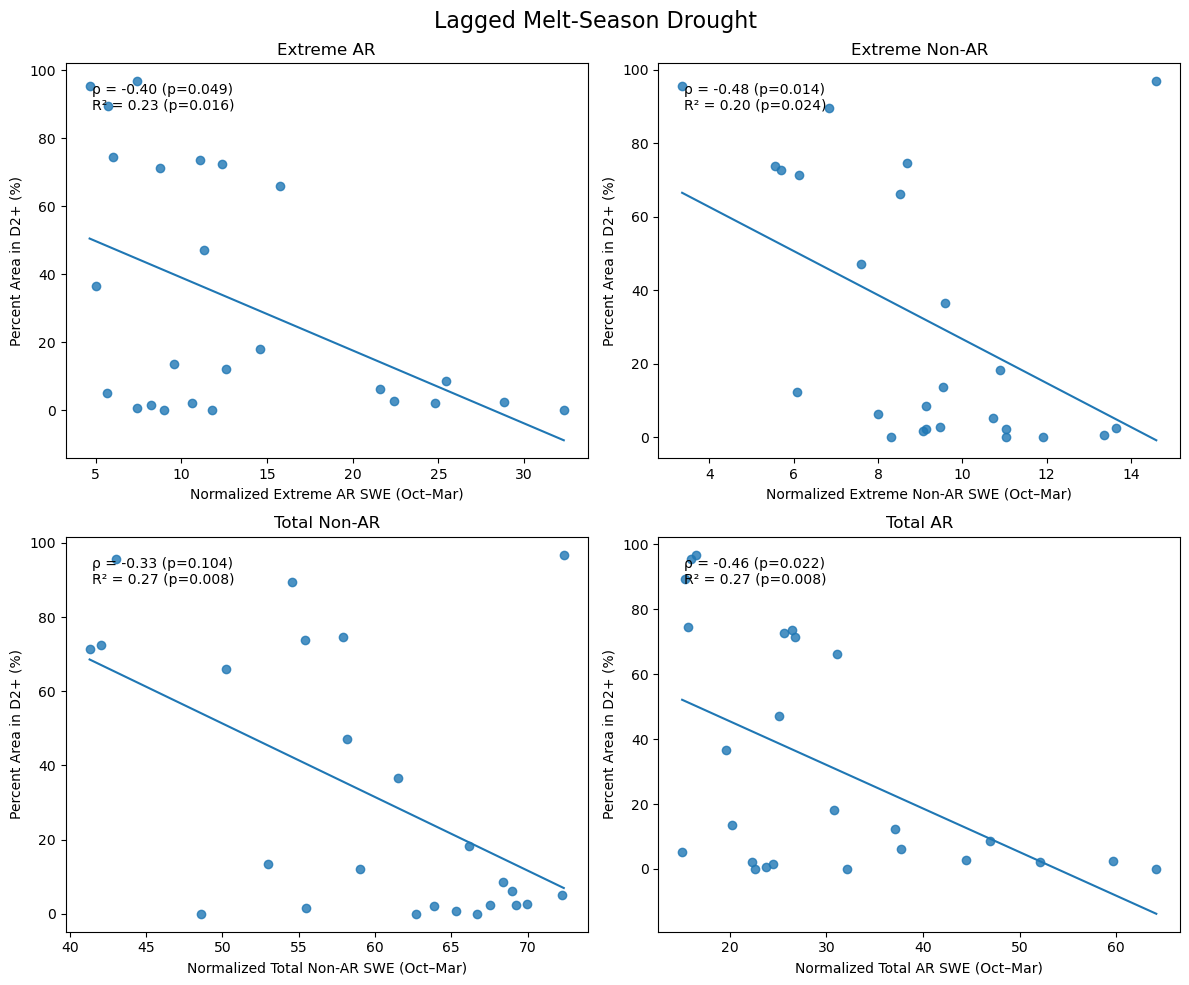

,Drought Metric,SWE Metric,Spearman_rho,Spearman_p,Linear_R2,Linear_p,Slope
6,Lagged Melt-Season Drought,Total Non-AR,-0.33,0.10,0.27,0.01,-1.98
7,Lagged Melt-Season Drought,Total AR,-0.46,0.02,0.27,0.01,-1.34
4,Lagged Melt-Season Drought,Extreme AR,-0.40,0.05,0.23,0.02,-2.14
5,Lagged Melt-Season Drought,Extreme Non-AR,-0.48,0.01,0.20,0.02,-5.99
3,Same-Year Drought,Total AR,-0.27,0.17,0.13,0.08,-0.81
0,Same-Year Drought,Extreme AR,-0.26,0.21,0.09,0.14,-1.19
1,Same-Year Drought,Extreme Non-AR,-0.32,0.11,0.02,0.49,-1.47
2,Same-Year Drought,Total Non-AR,-0.18,0.37,0.01,0.71,-0.19
